In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import hdbscan
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("✓ Librerías cargadas")

✓ Librerías cargadas


In [3]:
#Cargar las 3 representaciones
df_original = pd.read_csv('../data/processed/cereales_clean.csv')
df_normalized = pd.read_csv('../data/processed/cereales_normalized.csv')
df_pca = pd.read_csv('../data/processed/cereales_pca.csv')
df_ae = pd.read_csv('../data/processed/cereales_autoencoder.csv')

# Extraer matrices
cols_nutri = ['Energy', 'Protein', 'Carbohydrate, by difference',
              'Total lipid (fat)', 'Fatty acids, total saturated',
              'Fiber, total dietary', 'Total Sugars', 'Sodium, Na']

X_norm = df_normalized[cols_nutri].values
X_pca = df_pca[[c for c in df_pca.columns if c.startswith('PC')]].values
X_ae = df_ae[[c for c in df_ae.columns if c.startswith('AE')]].values

print(f"Datos normalizados: {X_norm.shape}")
print(f"PCA: {X_pca.shape}")
print(f"Autoencoder: {X_ae.shape}")

Datos normalizados: (11601, 8)
PCA: (11601, 5)
Autoencoder: (11601, 3)


In [4]:
def evaluar_clustering(X, labels, nombre=""):
    """Calcula métricas de evaluación para clustering"""
    # Filtrar ruido (-1) si existe
    mask = labels != -1

    if mask.sum() < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'n_clusters': 0}

    n_clusters = len(set(labels[mask]))

    if n_clusters < 2:
        return {'silhouette': np.nan, 'davies_bouldin': np.nan, 'n_clusters': n_clusters}

    sil = silhouette_score(X[mask], labels[mask])
    db = davies_bouldin_score(X[mask], labels[mask])

    return {
        'silhouette': sil,
        'davies_bouldin': db,
        'n_clusters': n_clusters,
        'n_ruido': (~mask).sum()
    }

In [5]:
# Probar diferentes valores de k
k_range = range(2, 15)
inertias = []
silhouettes = []

print("=== K-MEANS: MÉTODO DEL CODO ===")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_norm)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_norm, labels))
    print(f"k={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={silhouettes[-1]:.3f}")

=== K-MEANS: MÉTODO DEL CODO ===
k=2: Inertia=72545, Silhouette=0.339
k=3: Inertia=58260, Silhouette=0.280
k=4: Inertia=49251, Silhouette=0.286
k=5: Inertia=44149, Silhouette=0.284
k=6: Inertia=39740, Silhouette=0.282
k=7: Inertia=36685, Silhouette=0.228
k=8: Inertia=34473, Silhouette=0.230
k=9: Inertia=32539, Silhouette=0.235
k=10: Inertia=30642, Silhouette=0.242
k=11: Inertia=29347, Silhouette=0.243
k=12: Inertia=28027, Silhouette=0.233
k=13: Inertia=26944, Silhouette=0.230
k=14: Inertia=25924, Silhouette=0.230


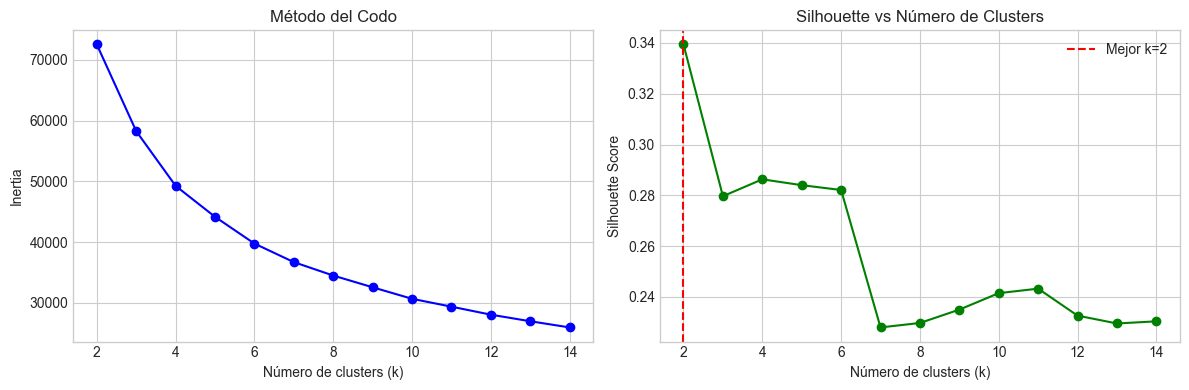

✓ Guardado: kmeans_elbow.png
Mejor k según Silhouette: 2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico del codo (Inertia)
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Método del Codo')

# Silhouette por k
axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette vs Número de Clusters')

# Marcar mejor k
best_k = k_range[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/kmeans_elbow.png', dpi=150)
plt.show()
print(f"✓ Guardado: kmeans_elbow.png")
print(f"Mejor k según Silhouette: {best_k}")

In [7]:
# Aplicar K-Means con el mejor k
k_optimo = best_k
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Aplicar sobre las 3 representaciones
labels_kmeans_norm = kmeans_final.fit_predict(X_norm)
labels_kmeans_pca = KMeans(n_clusters=k_optimo, random_state=42, n_init=10).fit_predict(X_pca)
labels_kmeans_ae = KMeans(n_clusters=k_optimo, random_state=42, n_init=10).fit_predict(X_ae)

# Evaluar
print(f"=== K-MEANS (k={k_optimo}) ===")
print(f"\nNormalizado: {evaluar_clustering(X_norm, labels_kmeans_norm)}")
print(f"PCA:         {evaluar_clustering(X_pca, labels_kmeans_pca)}")
print(f"Autoencoder: {evaluar_clustering(X_ae, labels_kmeans_ae)}")

=== K-MEANS (k=2) ===

Normalizado: {'silhouette': 0.33937467094923257, 'davies_bouldin': 1.4403275734677699, 'n_clusters': 2, 'n_ruido': np.int64(0)}
PCA:         {'silhouette': 0.3576824421717973, 'davies_bouldin': 1.3166513964140014, 'n_clusters': 2, 'n_ruido': np.int64(0)}
Autoencoder: {'silhouette': 0.44544013451755454, 'davies_bouldin': 0.8350929652260743, 'n_clusters': 2, 'n_ruido': np.int64(0)}


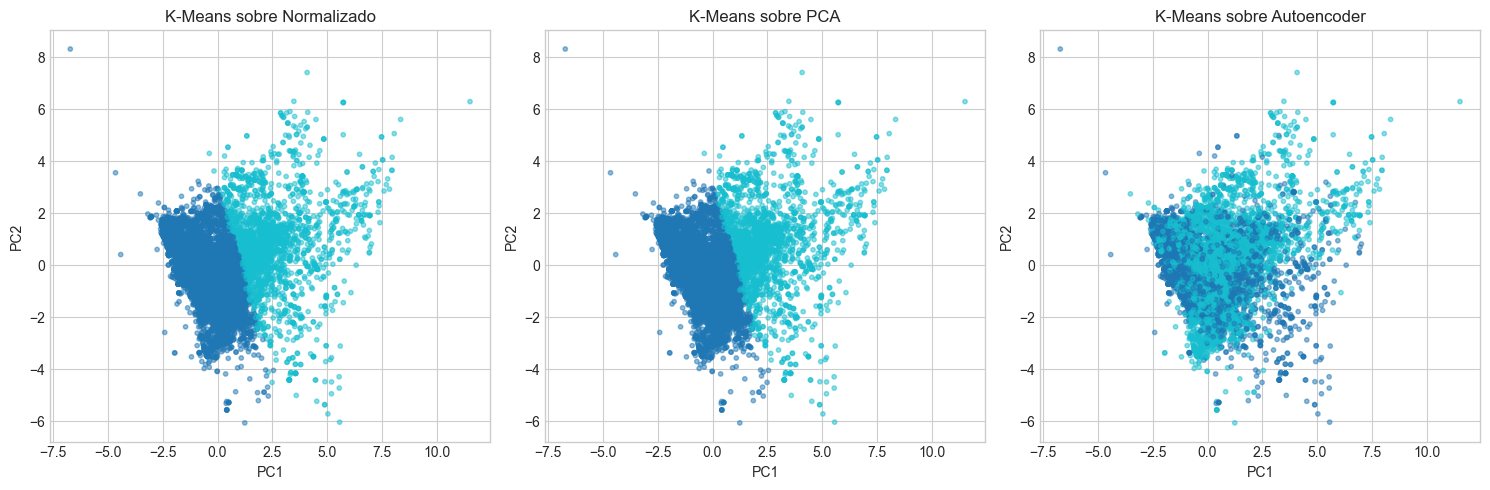

✓ Guardado: kmeans_clusters.png


In [8]:
from sklearn.decomposition import PCA

# Proyectar a 2D para visualización
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_norm)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, labels, titulo in zip(axes,
                               [labels_kmeans_norm, labels_kmeans_pca, labels_kmeans_ae],
                               ['Normalizado', 'PCA', 'Autoencoder']):
    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='tab10', alpha=0.5, s=10)
    ax.set_title(f'K-Means sobre {titulo}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('../docs/kmeans_clusters.png', dpi=150)
plt.show()
print("✓ Guardado: kmeans_clusters.png")

Calculando dendrograma (muestra de 1000 productos)...


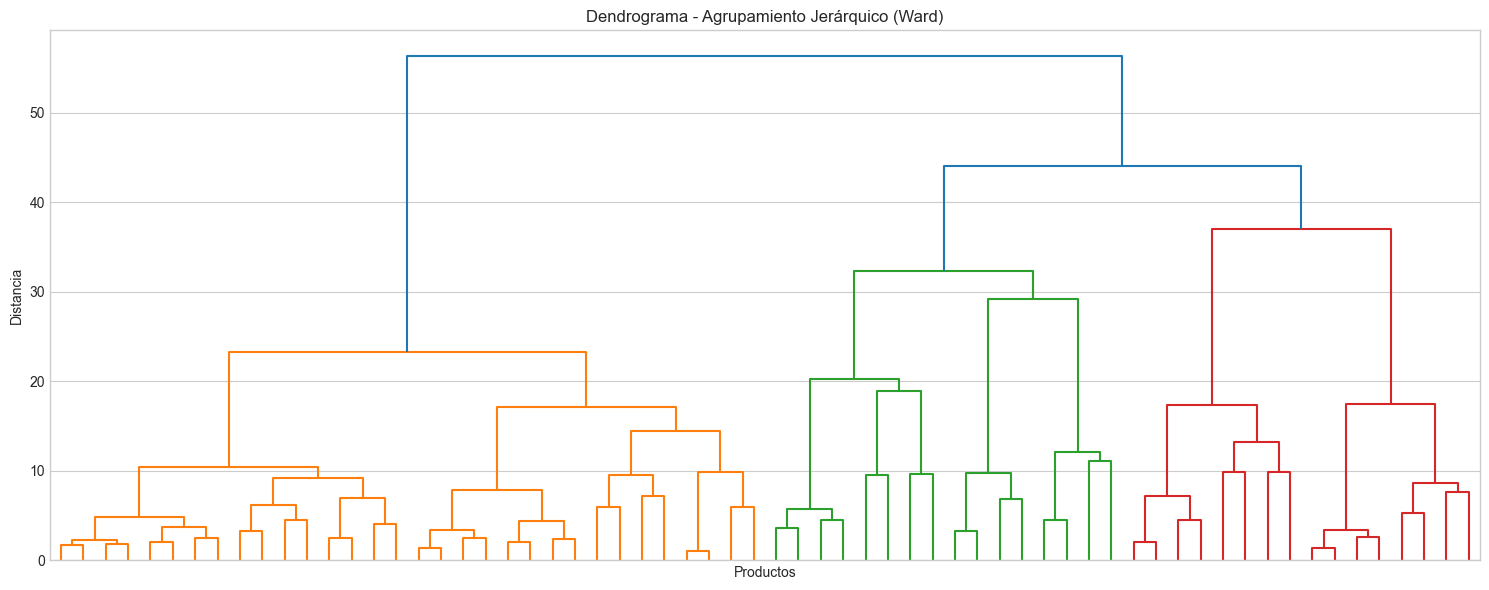

✓ Guardado: dendrograma.png


In [9]:
# Usar muestra para el dendrograma (muy pesado con 11k productos)
np.random.seed(42)
sample_idx = np.random.choice(len(X_norm), size=1000, replace=False)
X_sample = X_norm[sample_idx]

# Calcular linkage
print("Calculando dendrograma (muestra de 1000 productos)...")
Z = linkage(X_sample, method='ward')

# Visualizar
plt.figure(figsize=(15, 6))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True)
plt.title('Dendrograma - Agrupamiento Jerárquico (Ward)')
plt.xlabel('Productos')
plt.ylabel('Distancia')
plt.tight_layout()
plt.savefig('../docs/dendrograma.png', dpi=150)
plt.show()
print("✓ Guardado: dendrograma.png")

In [10]:
# Probar diferentes números de clusters
print("=== AGRUPAMIENTO JERÁRQUICO ===")
resultados_jerarquico = []

for n in [3, 5, 7, 10]:
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels_hc = hc.fit_predict(X_norm)
    metrics = evaluar_clustering(X_norm, labels_hc)
    resultados_jerarquico.append({
        'n_clusters': n,
        'silhouette': metrics['silhouette'],
        'davies_bouldin': metrics['davies_bouldin']
    })
    print(f"n={n}: Silhouette={metrics['silhouette']:.3f}, DB={metrics['davies_bouldin']:.3f}")

# Mejor configuración
mejor_hc = max(resultados_jerarquico, key=lambda x: x['silhouette'])
print(f"\nMejor: n={mejor_hc['n_clusters']} con Silhouette={mejor_hc['silhouette']:.3f}")

=== AGRUPAMIENTO JERÁRQUICO ===
n=3: Silhouette=0.189, DB=1.488
n=5: Silhouette=0.191, DB=1.587
n=7: Silhouette=0.201, DB=1.347
n=10: Silhouette=0.201, DB=1.309

Mejor: n=10 con Silhouette=0.201


In [11]:
# Probar diferentes números de clusters
print("=== AGRUPAMIENTO JERÁRQUICO ===")
resultados_jerarquico = []

for n in [3, 5, 7, 10]:
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels_hc = hc.fit_predict(X_norm)
    metrics = evaluar_clustering(X_norm, labels_hc)
    resultados_jerarquico.append({
        'n_clusters': n,
        'silhouette': metrics['silhouette'],
        'davies_bouldin': metrics['davies_bouldin']
    })
    print(f"n={n}: Silhouette={metrics['silhouette']:.3f}, DB={metrics['davies_bouldin']:.3f}")

# Mejor configuración
mejor_hc = max(resultados_jerarquico, key=lambda x: x['silhouette'])
print(f"\nMejor: n={mejor_hc['n_clusters']} con Silhouette={mejor_hc['silhouette']:.3f}")

=== AGRUPAMIENTO JERÁRQUICO ===
n=3: Silhouette=0.189, DB=1.488
n=5: Silhouette=0.191, DB=1.587
n=7: Silhouette=0.201, DB=1.347
n=10: Silhouette=0.201, DB=1.309

Mejor: n=10 con Silhouette=0.201


In [12]:
# Aplicar con mejor n
n_hc = mejor_hc['n_clusters']
hc_final = AgglomerativeClustering(n_clusters=n_hc, linkage='ward')

labels_hc_norm = hc_final.fit_predict(X_norm)
labels_hc_pca = AgglomerativeClustering(n_clusters=n_hc, linkage='ward').fit_predict(X_pca)
labels_hc_ae = AgglomerativeClustering(n_clusters=n_hc, linkage='ward').fit_predict(X_ae)

print(f"=== JERÁRQUICO (n={n_hc}) ===")
print(f"\nNormalizado: {evaluar_clustering(X_norm, labels_hc_norm)}")
print(f"PCA:         {evaluar_clustering(X_pca, labels_hc_pca)}")
print(f"Autoencoder: {evaluar_clustering(X_ae, labels_hc_ae)}")

=== JERÁRQUICO (n=10) ===

Normalizado: {'silhouette': 0.200702472486574, 'davies_bouldin': 1.3085698658720013, 'n_clusters': 10, 'n_ruido': np.int64(0)}
PCA:         {'silhouette': 0.18003439236055532, 'davies_bouldin': 1.2694262332113735, 'n_clusters': 10, 'n_ruido': np.int64(0)}
Autoencoder: {'silhouette': 0.2688183629866101, 'davies_bouldin': 1.0248662285122303, 'n_clusters': 10, 'n_ruido': np.int64(0)}


In [ ]:
#HDBSCAN

In [13]:
print("=== HDBSCAN ===")
resultados_hdbscan = []

# Probar diferentes configuraciones
configs = [
    {'min_cluster_size': 50, 'min_samples': 10},
    {'min_cluster_size': 100, 'min_samples': 10},
    {'min_cluster_size': 100, 'min_samples': 20},
    {'min_cluster_size': 200, 'min_samples': 20},
    {'min_cluster_size': 200, 'min_samples': 50},
]

for config in configs:
    clusterer = hdbscan.HDBSCAN(**config)
    labels = clusterer.fit_predict(X_norm)
    metrics = evaluar_clustering(X_norm, labels)

    resultados_hdbscan.append({
        **config,
        **metrics
    })
    print(f"min_cluster={config['min_cluster_size']}, min_samples={config['min_samples']}: "
          f"clusters={metrics['n_clusters']}, ruido={metrics.get('n_ruido', 0)}, "
          f"Silhouette={metrics['silhouette']:.3f}")

=== HDBSCAN ===
min_cluster=50, min_samples=10: clusters=26, ruido=7483, Silhouette=0.399
min_cluster=100, min_samples=10: clusters=2, ruido=914, Silhouette=0.511
min_cluster=100, min_samples=20: clusters=2, ruido=1333, Silhouette=0.536
min_cluster=200, min_samples=20: clusters=2, ruido=1333, Silhouette=0.536
min_cluster=200, min_samples=50: clusters=2, ruido=1374, Silhouette=0.542


In [14]:
# Filtrar configuraciones válidas (con silhouette no nan)
valid_hdbscan = [r for r in resultados_hdbscan if not np.isnan(r['silhouette'])]

if valid_hdbscan:
    mejor_hdbscan = max(valid_hdbscan, key=lambda x: x['silhouette'])
    print(f"\nMejor configuración HDBSCAN:")
    print(f"  min_cluster_size: {mejor_hdbscan['min_cluster_size']}")
    print(f"  min_samples: {mejor_hdbscan['min_samples']}")
    print(f"  Clusters: {mejor_hdbscan['n_clusters']}")
    print(f"  Silhouette: {mejor_hdbscan['silhouette']:.3f}")

    # Aplicar mejor configuración
    hdbscan_final = hdbscan.HDBSCAN(
        min_cluster_size=mejor_hdbscan['min_cluster_size'],
        min_samples=mejor_hdbscan['min_samples']
    )
    labels_hdbscan_norm = hdbscan_final.fit_predict(X_norm)
    labels_hdbscan_pca = hdbscan.HDBSCAN(
        min_cluster_size=mejor_hdbscan['min_cluster_size'],
        min_samples=mejor_hdbscan['min_samples']
    ).fit_predict(X_pca)
    labels_hdbscan_ae = hdbscan.HDBSCAN(
        min_cluster_size=mejor_hdbscan['min_cluster_size'],
        min_samples=mejor_hdbscan['min_samples']
    ).fit_predict(X_ae)
else:
    print("No se encontraron configuraciones válidas de HDBSCAN")
    labels_hdbscan_norm = np.zeros(len(X_norm))


Mejor configuración HDBSCAN:
  min_cluster_size: 200
  min_samples: 50
  Clusters: 2
  Silhouette: 0.542


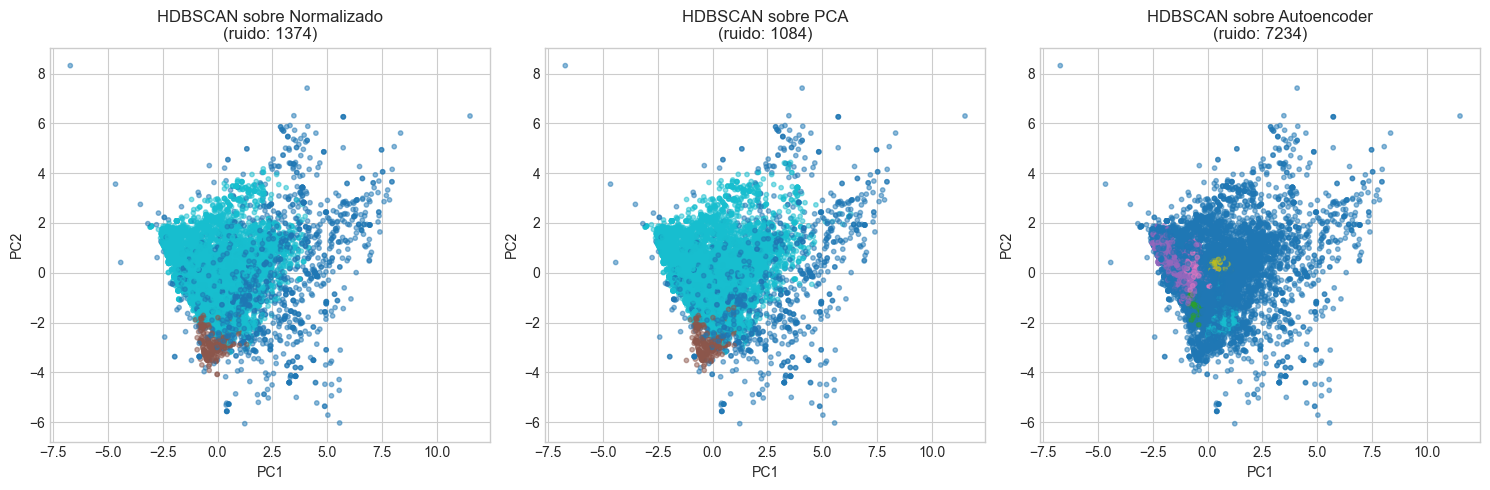

✓ Guardado: hdbscan_clusters.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, labels, titulo in zip(axes,
                               [labels_hdbscan_norm, labels_hdbscan_pca, labels_hdbscan_ae],
                               ['Normalizado', 'PCA', 'Autoencoder']):
    # Colorear ruido de gris
    colors = labels.copy().astype(float)
    colors[labels == -1] = -1

    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=colors, cmap='tab10', alpha=0.5, s=10)
    n_ruido = (labels == -1).sum()
    ax.set_title(f'HDBSCAN sobre {titulo}\n(ruido: {n_ruido})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('../docs/hdbscan_clusters.png', dpi=150)
plt.show()
print("✓ Guardado: hdbscan_clusters.png")

In [16]:
#COMPARACION DE RESULTADOS# Recopilar todos los resultados
resultados = []

# K-Means
for rep, labels, X in [('Normalizado', labels_kmeans_norm, X_norm),
                        ('PCA', labels_kmeans_pca, X_pca),
                        ('Autoencoder', labels_kmeans_ae, X_ae)]:
    m = evaluar_clustering(X, labels)
    resultados.append({
        'Algoritmo': 'K-Means',
        'Representación': rep,
        'Clusters': m['n_clusters'],
        'Silhouette': m['silhouette'],
        'Davies-Bouldin': m['davies_bouldin']
    })

# Jerárquico
for rep, labels, X in [('Normalizado', labels_hc_norm, X_norm),
                        ('PCA', labels_hc_pca, X_pca),
                        ('Autoencoder', labels_hc_ae, X_ae)]:
    m = evaluar_clustering(X, labels)
    resultados.append({
        'Algoritmo': 'Jerárquico',
        'Representación': rep,
        'Clusters': m['n_clusters'],
        'Silhouette': m['silhouette'],
        'Davies-Bouldin': m['davies_bouldin']
    })

# HDBSCAN
for rep, labels, X in [('Normalizado', labels_hdbscan_norm, X_norm),
                        ('PCA', labels_hdbscan_pca, X_pca),
                        ('Autoencoder', labels_hdbscan_ae, X_ae)]:
    m = evaluar_clustering(X, labels)
    resultados.append({
        'Algoritmo': 'HDBSCAN',
        'Representación': rep,
        'Clusters': m['n_clusters'],
        'Ruido': m.get('n_ruido', 0),
        'Silhouette': m['silhouette'],
        'Davies-Bouldin': m['davies_bouldin']
    })

df_resultados = pd.DataFrame(resultados)
print("=== COMPARACIÓN DE RESULTADOS ===")
print(df_resultados.to_string(index=False))

=== COMPARACIÓN DE RESULTADOS ===
 Algoritmo Representación  Clusters  Silhouette  Davies-Bouldin  Ruido
   K-Means    Normalizado         2    0.339375        1.440328    NaN
   K-Means            PCA         2    0.357682        1.316651    NaN
   K-Means    Autoencoder         2    0.445440        0.835093    NaN
Jerárquico    Normalizado        10    0.200702        1.308570    NaN
Jerárquico            PCA        10    0.180034        1.269426    NaN
Jerárquico    Autoencoder        10    0.268818        1.024866    NaN
   HDBSCAN    Normalizado         2    0.541513        0.537570 1374.0
   HDBSCAN            PCA         2    0.555796        0.515556 1084.0
   HDBSCAN    Autoencoder         5    0.519715        0.469510 7234.0


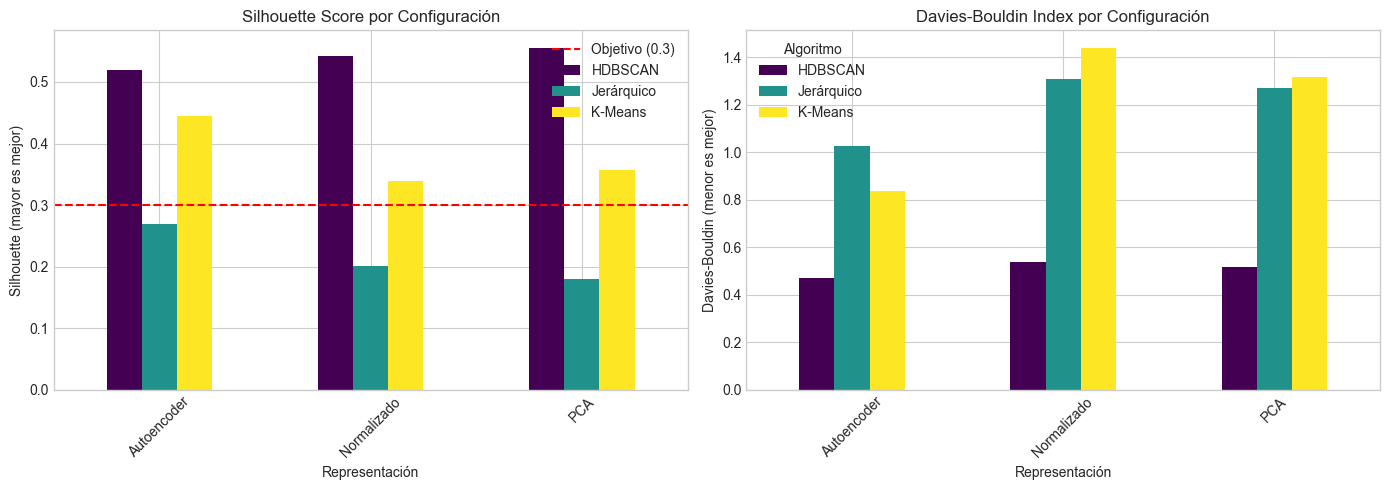

✓ Guardado: comparacion_clustering.png


In [17]:
# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette
df_pivot_sil = df_resultados.pivot(index='Representación', columns='Algoritmo', values='Silhouette')
df_pivot_sil.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Silhouette Score por Configuración')
axes[0].set_ylabel('Silhouette (mayor es mejor)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].axhline(y=0.3, color='red', linestyle='--', label='Objetivo (0.3)')
axes[0].legend()

# Davies-Bouldin
df_pivot_db = df_resultados.pivot(index='Representación', columns='Algoritmo', values='Davies-Bouldin')
df_pivot_db.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Davies-Bouldin Index por Configuración')
axes[1].set_ylabel('Davies-Bouldin (menor es mejor)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../docs/comparacion_clustering.png', dpi=150)
plt.show()
print("✓ Guardado: comparacion_clustering.png")

In [18]:
# Encontrar mejor configuración
mejor = df_resultados.loc[df_resultados['Silhouette'].idxmax()]

print("=" * 60)
print("MEJOR CONFIGURACIÓN")
print("=" * 60)
print(f"Algoritmo:      {mejor['Algoritmo']}")
print(f"Representación: {mejor['Representación']}")
print(f"Clusters:       {mejor['Clusters']}")
print(f"Silhouette:     {mejor['Silhouette']:.3f}")
print(f"Davies-Bouldin: {mejor['Davies-Bouldin']:.3f}")

# Verificar objetivo OE7
if mejor['Silhouette'] >= 0.3:
    print(f"\n✓ OBJETIVO OE7 CUMPLIDO: Silhouette ≥ 0.3")
else:
    print(f"\n✗ Objetivo OE7 no alcanzado (Silhouette < 0.3)")

MEJOR CONFIGURACIÓN
Algoritmo:      HDBSCAN
Representación: PCA
Clusters:       2
Silhouette:     0.556
Davies-Bouldin: 0.516

✓ OBJETIVO OE7 CUMPLIDO: Silhouette ≥ 0.3


In [19]:
# Guardar etiquetas del mejor modelo
if mejor['Algoritmo'] == 'K-Means' and mejor['Representación'] == 'Normalizado':
    labels_mejor = labels_kmeans_norm
elif mejor['Algoritmo'] == 'K-Means' and mejor['Representación'] == 'PCA':
    labels_mejor = labels_kmeans_pca
elif mejor['Algoritmo'] == 'K-Means' and mejor['Representación'] == 'Autoencoder':
    labels_mejor = labels_kmeans_ae
elif mejor['Algoritmo'] == 'Jerárquico' and mejor['Representación'] == 'Normalizado':
    labels_mejor = labels_hc_norm
elif mejor['Algoritmo'] == 'Jerárquico' and mejor['Representación'] == 'PCA':
    labels_mejor = labels_hc_pca
elif mejor['Algoritmo'] == 'Jerárquico' and mejor['Representación'] == 'Autoencoder':
    labels_mejor = labels_hc_ae
elif mejor['Algoritmo'] == 'HDBSCAN' and mejor['Representación'] == 'Normalizado':
    labels_mejor = labels_hdbscan_norm
elif mejor['Algoritmo'] == 'HDBSCAN' and mejor['Representación'] == 'PCA':
    labels_mejor = labels_hdbscan_pca
else:
    labels_mejor = labels_hdbscan_ae

# Añadir al dataframe original
df_original['cluster'] = labels_mejor
df_original.to_csv('../data/processed/cereales_clustered.csv', index=False)
print("✓ Guardado: cereales_clustered.csv")

# Guardar resultados
df_resultados.to_csv('../data/processed/resultados_clustering.csv', index=False)
print("✓ Guardado: resultados_clustering.csv")

✓ Guardado: cereales_clustered.csv
✓ Guardado: resultados_clustering.csv


In [20]:
#RESUMEN

In [22]:
print("=" * 60)
print("RESUMEN FASE 3: CLUSTERING")
print("=" * 60)

print(f"\n1. K-MEANS")
print(f"   k óptimo: {k_optimo}")
print(f"   Mejor Silhouette: {df_resultados[df_resultados['Algoritmo']=='K-Means']['Silhouette'].max():.3f}")

print(f"\n2. JERÁRQUICO")
print(f"   n óptimo: {n_hc}")
print(f"   Mejor Silhouette: {df_resultados[df_resultados['Algoritmo']=='Jerárquico']['Silhouette'].max():.3f}")

print(f"\n3. HDBSCAN")
if valid_hdbscan:
    print(f"   Mejor config: min_cluster={mejor_hdbscan['min_cluster_size']}, min_samples={mejor_hdbscan['min_samples']}")
    print(f"   Mejor Silhouette: {df_resultados[df_resultados['Algoritmo']=='HDBSCAN']['Silhouette'].max():.3f}")

print(f"\nMEJOR GLOBAL: {mejor['Algoritmo']} + {mejor['Representación']}")
print(f"Silhouette: {mejor['Silhouette']:.3f}")

print(f"\n" + "=" * 60)
print("ARCHIVOS GENERADOS:")
print("=" * 60)
print("  data/processed/cereales_clustered.csv")
print("  data/processed/resultados_clustering.csv")
print("  docs/kmeans_elbow.png")
print("  docs/kmeans_clusters.png")
print("  docs/dendrograma.png")
print("  docs/hdbscan_clusters.png")
print("  docs/comparacion_clustering.png")

print(f"\n✓ Fase 3 (Clustering) completada")

RESUMEN FASE 3: CLUSTERING

1. K-MEANS
   k óptimo: 2
   Mejor Silhouette: 0.445

2. JERÁRQUICO
   n óptimo: 10
   Mejor Silhouette: 0.269

3. HDBSCAN
   Mejor config: min_cluster=200, min_samples=50
   Mejor Silhouette: 0.556

MEJOR GLOBAL: HDBSCAN + PCA
Silhouette: 0.556

ARCHIVOS GENERADOS:
  data/processed/cereales_clustered.csv
  data/processed/resultados_clustering.csv
  docs/kmeans_elbow.png
  docs/kmeans_clusters.png
  docs/dendrograma.png
  docs/hdbscan_clusters.png
  docs/comparacion_clustering.png

✓ Fase 3 (Clustering) completada
